In [1]:
from sklearn.datasets import fetch_california_housing
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

data = fetch_california_housing(as_frame=True)
df = data.frame

df.head()


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [2]:
df.info()
print("\nMissing values:\n", df.isnull().sum())

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB

Missing values:
 MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64


In [3]:
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


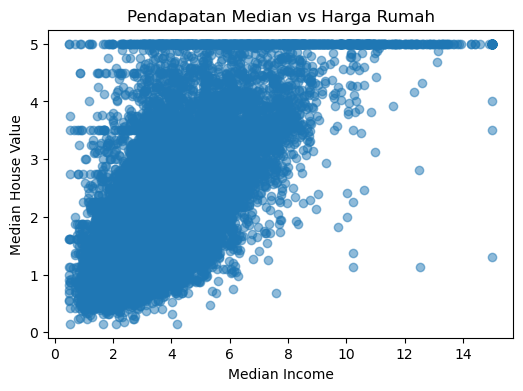

In [4]:
plt.figure(figsize=(6,4))
plt.scatter(df["MedInc"], df["MedHouseVal"], alpha=0.5)
plt.title("Pendapatan Median vs Harga Rumah")
plt.xlabel("Median Income")
plt.ylabel("Median House Value")
plt.show()

Terdapat hubungan positif antara pendapatan median dan harga rumah, semakin tinggi pendapatan, harga rumah cenderung meningkat. Pola ini terlihat linear meskipun terdapat persebaran data cukup luas, terutama pada pendapatan yang lebih tinggi 

In [5]:
X = df[["MedInc"]]
y = df["MedHouseVal"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model_simple = LinearRegression()
model_simple.fit(X_train, y_train)

print("Intercept:", model_simple.intercept_)
print("Coefficient:", model_simple.coef_[0])


Intercept: 0.4445972916907883
Coefficient: 0.41933849393812694


In [6]:
y_pred = model_simple.predict(X_test)
y_train_pred = model_simple.predict(X_train)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)
r2_train = r2_score(y_train, y_train_pred)


print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2:", r2)
print("R2 Train:", r2_train)

MAE: 0.629908653009376
MSE: 0.7091157771765548
RMSE: 0.8420901241414454
R2: 0.45885918903846656
R2 Train: 0.4769927345820524


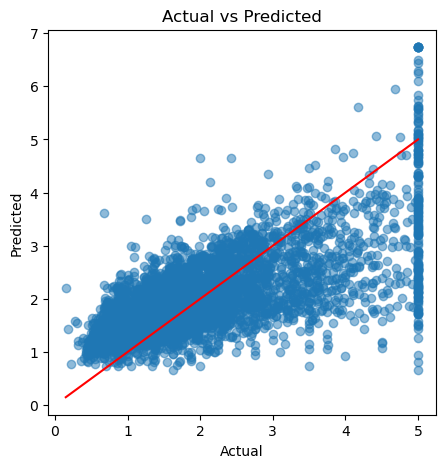

In [7]:
plt.figure(figsize=(5,5))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color="red")
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")
plt.show()


In [8]:
X_all = df.drop(columns=["MedHouseVal"])
y_all = df["MedHouseVal"]

X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X_all, y_all, test_size=0.2, random_state=42
)

model_multi = LinearRegression()
model_multi.fit(X_train2, y_train2)

y_train_pred = model_multi.predict(X_train2)
y_test_pred = model_multi.predict(X_test2)

def evaluate(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    return mae, mse, rmse, r2

mae_tr, mse_tr, rmse_tr, r2_tr = evaluate(y_train2, y_train_pred)

mae_te, mse_te, rmse_te, r2_te = evaluate(y_test2, y_test_pred)

print("TRAIN -> MAE:", mae_tr, "R2:", r2_tr)
print("TEST  -> MAE:", mae_te, "R2:", r2_te)

TRAIN -> MAE: 0.5286283596581923 R2: 0.6125511913966952
TEST  -> MAE: 0.5332001304956555 R2: 0.575787706032451


| Model  | R2 Train | R2 Test |
| -------- | -------- | -------- |
| Simple LR | 0.4769927345820524 | 0.45885918903846656|
| Multiple LR | 0.6125511913966952 | 0.575787706032451 |

Model termasuk good fit, karena nilai R² pada training dan test relatif dekat dan tidak menunjukkan gap besar.

Ini berarti model mampu melakukan generalisasi dengan baik tanpa overfitting. 

Selain itu, peningkatan dari model simple ke multiple regression menunjukkan bahwa fitur tambahan memberikan informasi penting dalam prediksi. 

Namun, nilai R² yang belum mendekati 1 menunjukkan masih ada variabel lain yang belum tertangkap model.

In [9]:
mape = np.mean(np.abs((y_test2 - y_test_pred) / y_test2)) * 100
print("MAPE:", mape)

MAPE: 31.95218741361491


MAPE sebesar ~32% berarti rata-rata prediksi harga rumah meleset sekitar 32% dari nilai sebenarnya. 

Dalam konteks dataset ini berarti estimasi harga masih memiliki deviasi cukup besar sehingga dapat mempengaruhi keputusan investasi atau penetapan harga.

Beberapa langkah perbaikan yang dapat dilakukan : 

Menambahkan feature engineering seperti interaksi antar variabel atau transformasi data.

Penggunaan model yang lebih kompleks seperti Random Forest.